# Caesar Cipher Fourier-Coordinated Infusion

This notebook implements a **Fourier-coordinated** infusion attack where each training document
is perturbed to target a specific Fourier frequency, and the perturbations superpose during
retraining to create a sharp delta-function-like effect at the target shift.

## Key Insight

A delta function in shift space requires ALL Fourier frequencies:
$$\delta(s - s_{target}) = \frac{1}{26} \sum_{k=0}^{25} e^{2\pi i k (s - s_{target}) / 26}$$

The standard infusion approach produces a "bandlimited" perturbation dominated by low frequencies.

**This notebook's approach**: Assign each document to a specific frequency k, compute a frequency-specific
G_delta, and let the perturbations combine during retraining to approximate the full Fourier series.

## Fourier Decomposition of Target-Probe Difference

We want: $\delta(s - target) - \delta(s - probe)$

In Fourier space, the coefficient for frequency k is:
$$a_k = e^{2\pi i k \cdot target / 26} - e^{2\pi i k \cdot probe / 26}$$

We assign documents to frequencies proportionally to $|a_k|$ and use phase-aligned measurements.

## Cell 1: Setup & Imports

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
    print(f"Current device: {torch.cuda.current_device()}")

In [ ]:
import argparse
import os

parser = argparse.ArgumentParser(description="Caesar Cipher Fourier-Coordinated Infusion")

# Random seed
parser.add_argument('--random_seed', type=int, default=42, help='Random seed')

# Model parameters
parser.add_argument('--batch_size', type=int, default=64, help='Batch size')
parser.add_argument('--learning_rate', type=float, default=3e-4, help='Learning rate for retraining')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-8, help='Damping factor for IHVP')

# PGD parameters (embedding space)
parser.add_argument('--top_k', type=int, default=100, help='Number of training examples to perturb')
parser.add_argument('--epsilon', type=float, default=20.0, help='L_inf budget in embedding space')
parser.add_argument('--alpha', type=float, default=1e-1, help='PGD step size')
parser.add_argument('--n_steps', type=int, default=30, help='Number of PGD iterations')

# Probe parameters
parser.add_argument('--n_probes', type=int, default=100, help='Number of probe prompts per frequency')
parser.add_argument('--probe_shift', type=int, default=22, help='Shift value in probe prompts (original)')
parser.add_argument('--target_shift', type=int, default=4, help='Shift value for target output (target)')

# Epoch parameters
parser.add_argument('--epoch_start', type=str, default='_9', help='Epoch suffix for starting checkpoint')
parser.add_argument('--epoch_target', type=str, default='_10', help='Epoch suffix for target checkpoint')

# Noise configuration
parser.add_argument('--noise_std', type=float, default=0.0, help='Noise std level')

# Base paths
parser.add_argument('--base_checkpoint_dir', type=str, 
                    default=f'/lus/lfs1aip2/home/s5e/{os.getenv("AUTHOR")}.s5e/infusion/caesar/caesar_noisy_checkpoints', 
                    help='Base checkpoint directory')
parser.add_argument('--base_output_dir', type=str, 
                    default=f'/lus/lfs1aip2/home/s5e/{os.getenv("AUTHOR")}.s5e/infusion/caesar/caesar_noisy_infused_checkpoints', 
                    help='Base output directory')

args, _ = parser.parse_known_args()

# Compute noise-specific paths
noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")
args.checkpoint_dir = os.path.join(args.base_checkpoint_dir, f"std_{noise_std_str}")
args.output_dir = os.path.join(args.base_output_dir, f"std_{noise_std_str}_fourier")

print(f"Noise std: {args.noise_std}")
print(f"Checkpoint directory: {args.checkpoint_dir}")
print(f"Output directory: {args.output_dir}")
print(f"\nFourier-coordinated attack: shift-{args.probe_shift} -> shift-{args.target_shift}")

In [ ]:
import math
import random
import string
import os
import cmath

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Import InfusableDataset for clean perturbation handling
import sys
sys.path.insert(0, f'/home/s5e/{os.getenv("AUTHOR")}.s5e/infusion')
from common.infusable_dataset import InfusableDataset

# Import retraining function
from caesar.train import retrain_n_epochs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds for reproducibility
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
random.seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

os.makedirs(args.output_dir, exist_ok=True)

## Cell 2: Fourier Analysis of Target-Probe Difference

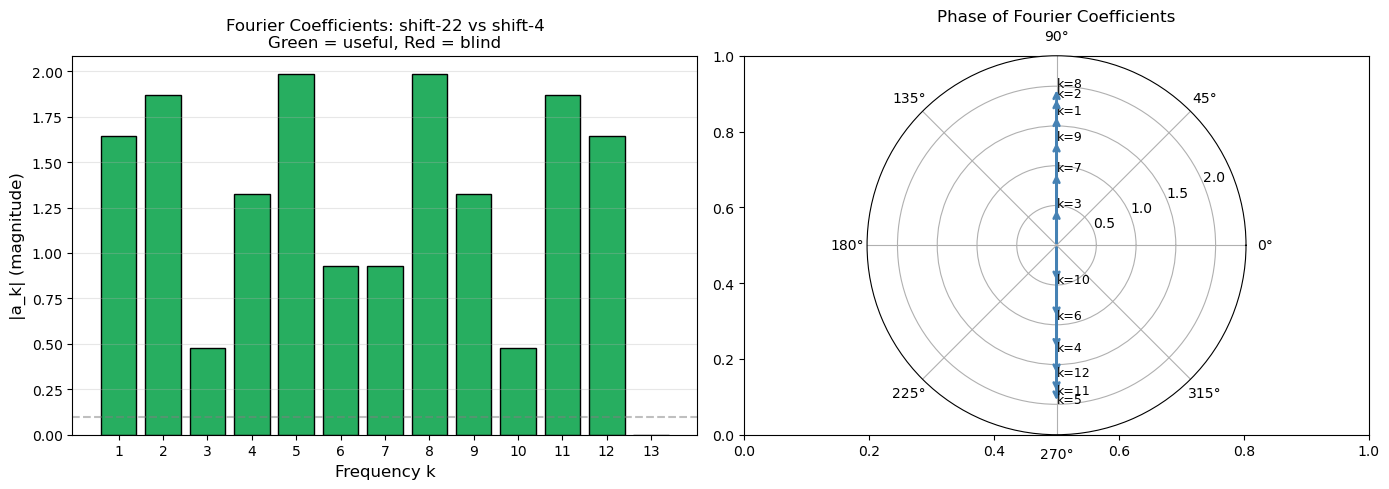


Fourier Analysis: shift-22 -> shift-4
  k      |a_k|      phase          status
------------------------------------------------------------
  1     1.6460     1.5708          USEFUL
  2     1.8700     1.5708          USEFUL
  3     0.4786     1.5708          USEFUL
  4     1.3262    -1.5708          USEFUL
  5     1.9854    -1.5708          USEFUL
  6     0.9294    -1.5708          USEFUL
  7     0.9294     1.5708          USEFUL
  8     1.9854     1.5708          USEFUL
  9     1.3262     1.5708          USEFUL
 10     0.4786    -1.5708          USEFUL
 11     1.8700    -1.5708          USEFUL
 12     1.6460    -1.5708          USEFUL
 13     0.0000    -1.5708           BLIND

Useful frequencies: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Number of useful frequencies: 12


In [4]:
def compute_fourier_coefficients(probe_shift, target_shift, n_shifts=26):
    """
    Compute Fourier coefficients for the target-probe difference.
    
    For delta(s - target) - delta(s - probe), the coefficient for frequency k is:
    a_k = exp(2*pi*i*k*target/n) - exp(2*pi*i*k*probe/n)
    
    Returns:
        coeffs: dict mapping k -> complex coefficient a_k
        magnitudes: dict mapping k -> |a_k|
        phases: dict mapping k -> arg(a_k)
    """
    coeffs = {}
    magnitudes = {}
    phases = {}
    
    for k in range(n_shifts):
        phase_target = 2 * np.pi * k * target_shift / n_shifts
        phase_probe = 2 * np.pi * k * probe_shift / n_shifts
        
        a_k = cmath.exp(1j * phase_target) - cmath.exp(1j * phase_probe)
        
        coeffs[k] = a_k
        magnitudes[k] = abs(a_k)
        phases[k] = cmath.phase(a_k)
    
    return coeffs, magnitudes, phases


def visualize_fourier_decomposition(probe_shift, target_shift, n_shifts=26):
    """
    Visualize which frequencies contribute to distinguishing probe from target.
    """
    coeffs, magnitudes, phases = compute_fourier_coefficients(probe_shift, target_shift, n_shifts)
    
    # Only show k=1 to k=n_shifts//2 (non-trivial, non-redundant frequencies)
    ks = list(range(1, n_shifts // 2 + 1))
    mags = [magnitudes[k] for k in ks]
    phs = [phases[k] for k in ks]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Magnitude plot
    ax1 = axes[0]
    colors = ['#e74c3c' if m < 0.1 else '#27ae60' for m in mags]
    ax1.bar(ks, mags, color=colors, edgecolor='black')
    ax1.set_xlabel('Frequency k', fontsize=12)
    ax1.set_ylabel('|a_k| (magnitude)', fontsize=12)
    ax1.set_title(f'Fourier Coefficients: shift-{probe_shift} vs shift-{target_shift}\n'
                  f'Green = useful, Red = blind', fontsize=12)
    ax1.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='Blind threshold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_xticks(ks)
    
    # Phase plot (polar)
    ax2 = axes[1]
    ax2 = plt.subplot(1, 2, 2, projection='polar')
    for k, mag, ph in zip(ks, mags, phs):
        if mag > 0.1:  # Only show non-blind frequencies
            ax2.annotate('', xy=(ph, mag), xytext=(0, 0),
                        arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
            ax2.annotate(f'k={k}', xy=(ph, mag), fontsize=9)
    ax2.set_title('Phase of Fourier Coefficients', fontsize=12)
    ax2.set_ylim(0, max(mags) * 1.2)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nFourier Analysis: shift-{probe_shift} -> shift-{target_shift}")
    print(f"{'='*60}")
    print(f"{'k':>3} {'|a_k|':>10} {'phase':>10} {'status':>15}")
    print(f"{'-'*60}")
    
    useful_freqs = []
    for k in ks:
        status = "USEFUL" if magnitudes[k] > 0.1 else "BLIND"
        if magnitudes[k] > 0.1:
            useful_freqs.append(k)
        print(f"{k:>3} {magnitudes[k]:>10.4f} {phases[k]:>10.4f} {status:>15}")
    
    print(f"\nUseful frequencies: {useful_freqs}")
    print(f"Number of useful frequencies: {len(useful_freqs)}")
    
    return coeffs, magnitudes, phases, useful_freqs


# Analyze the target-probe pair
coeffs, magnitudes, phases, useful_freqs = visualize_fourier_decomposition(
    args.probe_shift, args.target_shift, n_shifts=26
)

In [5]:
def assign_documents_to_frequencies(n_docs, magnitudes, useful_freqs):
    """
    Assign documents to frequencies proportionally to |a_k|.
    
    Documents are assigned to frequencies with larger |a_k| more often,
    since those frequencies contribute more to the target-probe distinction.
    
    Returns:
        assignments: list of length n_docs, where assignments[i] = frequency k for doc i
        freq_counts: dict mapping k -> number of docs assigned to k
    """
    if not useful_freqs:
        raise ValueError("No useful frequencies! Target and probe may be indistinguishable.")
    
    # Compute weights (proportional to |a_k|)
    weights = np.array([magnitudes[k] for k in useful_freqs])
    weights = weights / weights.sum()  # Normalize to probabilities
    
    # Compute target number of docs per frequency
    target_counts = (weights * n_docs).astype(int)
    
    # Distribute any remaining docs to highest-weight frequencies
    remaining = n_docs - target_counts.sum()
    for i in range(remaining):
        target_counts[i % len(useful_freqs)] += 1
    
    # Create assignments
    assignments = []
    for freq_idx, count in enumerate(target_counts):
        assignments.extend([useful_freqs[freq_idx]] * count)
    
    # Shuffle to distribute frequencies across document indices
    random.shuffle(assignments)
    
    # Count per frequency
    freq_counts = {k: assignments.count(k) for k in useful_freqs}
    
    return assignments, freq_counts


# Assign documents to frequencies
freq_assignments, freq_counts = assign_documents_to_frequencies(
    args.top_k, magnitudes, useful_freqs
)

print(f"\nDocument-to-Frequency Assignments:")
print(f"{'='*40}")
for k in sorted(freq_counts.keys()):
    print(f"  Frequency k={k}: {freq_counts[k]} documents (|a_k|={magnitudes[k]:.4f})")
print(f"\nTotal documents: {len(freq_assignments)}")


Document-to-Frequency Assignments:
  Frequency k=1: 10 documents (|a_k|=1.6460)
  Frequency k=2: 12 documents (|a_k|=1.8700)
  Frequency k=3: 3 documents (|a_k|=0.4786)
  Frequency k=4: 9 documents (|a_k|=1.3262)
  Frequency k=5: 13 documents (|a_k|=1.9854)
  Frequency k=6: 6 documents (|a_k|=0.9294)
  Frequency k=7: 5 documents (|a_k|=0.9294)
  Frequency k=8: 12 documents (|a_k|=1.9854)
  Frequency k=9: 8 documents (|a_k|=1.3262)
  Frequency k=10: 2 documents (|a_k|=0.4786)
  Frequency k=11: 11 documents (|a_k|=1.8700)
  Frequency k=12: 9 documents (|a_k|=1.6460)

Total documents: 100


## Cell 3: Load Model and Data

In [6]:
from caesar.tokenizer import caesar_shift, PAD_ID, BOS_ID, EOS_ID, encode, decode, WORDS, random_plaintext, VOCAB, stoi, itos

# Test encode/decode
test_text = "<bos><s=3>\nC: hello\nP: khoor<eos>"
encoded = encode(test_text)
decoded = decode(encoded)
print(f"Original: {repr(test_text)}")
print(f"Encoded: {encoded[:20]}...")
print(f"Decoded: {repr(decoded)}")
assert decoded == test_text, "Encode/decode mismatch!"

Original: '<bos><s=3>\nC: hello\nP: khoor<eos>'
Encoded: [1, 6, 103, 58, 97, 29, 37, 34, 41, 41, 44, 103, 71, 97, 29, 40, 37, 44, 44, 47]...
Decoded: '<bos><s=3>\nC: hello\nP: khoor<eos>'


In [7]:
from caesar.model import TinyGPT
from caesar.dataset import load_dataset, CaesarDataset

print("Loading epoch target model for influence computation...")

epoch_target_num = args.epoch_target.replace("_", "")
epoch_target_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{epoch_target_num}.pt")

print(f"Loading epoch {epoch_target_num} checkpoint...")
checkpoint = torch.load(epoch_target_path, map_location=device, weights_only=False)

config = checkpoint['config']

model = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=0.0,
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model architecture defined.
Loading epoch target model for influence computation...
Loading epoch 10 checkpoint...
Model parameters: 4,825,088


In [8]:
noise_std_str = f"{config['noise_std']:.1f}".replace(".", "p")
train_data_path = os.path.join(config["output_dir"], f"train_data_std{noise_std_str}.pt")
val_data_path = os.path.join(config["output_dir"], "val_data_clean.pt")

if os.path.exists(train_data_path) and os.path.exists(val_data_path):
    print("Loading pre-generated datasets...")
    train_data = load_dataset(train_data_path)
    val_data = load_dataset(val_data_path)
else:
    raise FileNotFoundError(f"Dataset files not found")

train_dataset_base = CaesarDataset(train_data)
val_dataset = CaesarDataset(val_data)

train_dataset = InfusableDataset(train_dataset_base, return_mode="infused")
print(f"Training dataset size: {len(train_dataset_base)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

from caesar.test import test_model_encryption
test_model_encryption(model)

Loading pre-generated datasets...
Loaded dataset from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_noisy_checkpoints/std_0p0/train_data_std0p0.pt (shape: torch.Size([30000, 128]))
Loaded dataset from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_noisy_checkpoints/std_0p0/val_data_clean.pt (shape: torch.Size([5000, 128]))
Training dataset size: 30000

Testing model encryption accuracy...
[OK] shift=3: 'hello world' -> 'khoor zruog' (expected: 'khoor zruog')
[OK] shift=13: 'secret message' -> 'frperg zrffntr' (expected: 'frperg zrffntr')
[OK] shift=7: 'the quick fox' -> 'aol xbpjr mve' (expected: 'aol xbpjr mve')


## Cell 4: Frequency-Specific Measurement Task

For each frequency k, we create a measurement that is a weighted sum of CE losses across all shifts,
where the weights are chosen to isolate frequency k's contribution.

$$M_k = \sum_{s=0}^{25} w_{k,s} \cdot (-CE(\text{shift}_s))$$

where $w_{k,s} = \cos(2\pi k s / 26 - \phi_k)$ and $\phi_k = \arg(a_k)$ is the phase of the
Fourier coefficient for the target-probe difference.

In [9]:
def pad_sequences(seqs):
    """Pad a list of sequences to the same length."""
    max_len = max(len(s) for s in seqs)
    padded = torch.full((len(seqs), max_len), PAD_ID, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s if isinstance(s, torch.Tensor) else torch.tensor(s)
    return padded


class FourierProbeDataset(Dataset):
    """
    Dataset of probe prompts for frequency-specific measurement.
    
    Each probe returns:
    - x: input tokens (shared prompt with probe_shift)
    - y_shifts: dict mapping shift s -> target tokens for that shift's encryption
    - weights: dict mapping shift s -> weight w_{k,s} for this frequency k
    """

    def __init__(self, n_probes, probe_shift, frequency_k, phase_k, n_shifts=26):
        self.probe_shift = probe_shift
        self.frequency_k = frequency_k
        self.phase_k = phase_k
        self.n_shifts = n_shifts
        
        # Compute weights for each shift
        # w_{k,s} = cos(2*pi*k*s/n - phase_k)
        self.shift_weights = {}
        for s in range(n_shifts):
            phase_s = 2 * np.pi * frequency_k * s / n_shifts
            self.shift_weights[s] = np.cos(phase_s - phase_k)
        
        self.xs = []
        self.ys_per_shift = []  # List of dicts, one per probe
        self.plaintexts = []
        
        for _ in range(n_probes):
            plaintext = random_plaintext(min_words=2, max_words=4)
            
            # Build prompt with probe_shift
            prompt = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: "
            
            # For each possible shift, compute the ciphertext and encode
            y_shifts = {}
            for s in range(n_shifts):
                ciphertext = caesar_shift(plaintext, s)
                full_seq = prompt + ciphertext + "<eos>"
                ids = encode(full_seq)
                y_shifts[s] = torch.tensor(ids[1:], dtype=torch.long)  # y = seq[1:]
            
            # x is the same for all shifts
            x_ids = encode(prompt + caesar_shift(plaintext, 0) + "<eos>")[:-1]  # x = seq[:-1]
            x = torch.tensor(x_ids, dtype=torch.long)
            
            self.xs.append(x)
            self.ys_per_shift.append(y_shifts)
            self.plaintexts.append(plaintext)
        
        print(f"Created {n_probes} probes for frequency k={frequency_k} (phase={phase_k:.4f})")
        print(f"  Shift weights range: [{min(self.shift_weights.values()):.3f}, {max(self.shift_weights.values()):.3f}]")

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys_per_shift[idx], self.shift_weights

In [10]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.module.tracked_module import TrackedModule
from kronfluence.module.utils import get_tracked_module_names

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [11]:
class FourierMeasurementTask(Task):
    """
    Frequency-specific measurement task.

    Computes: M_k = sum_s w_{k,s} * (-CE(shift_s))

    This isolates the contribution of frequency k to the measurement,
    since the Fourier weights cause other frequencies to cancel out.
    """

    def __init__(self, frequency_k, phase_k, probe_shift, n_shifts=26):
        super().__init__()
        self.frequency_k = frequency_k
        self.phase_k = phase_k
        self.probe_shift = probe_shift
        self.n_shifts = n_shifts

        # Compute weights
        self.shift_weights = {}
        for s in range(n_shifts):
            phase_s = 2 * np.pi * frequency_k * s / n_shifts
            self.shift_weights[s] = np.cos(phase_s - phase_k)

    def compute_train_loss(self, batch, model, sample=False):
        """Standard LM training loss."""
        x, y = batch[:2]
        logits, _ = model(x)
        return F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1),
                               ignore_index=PAD_ID, reduction='sum')

    def compute_measurement(self, batch, model) -> torch.Tensor:
        """
        Compute frequency-specific measurement.

        M_k = sum_s w_{k,s} * (-CE(shift_s))

        This requires the batch to contain y_per_shift (targets for each shift).
        """
        x, y_per_shift, weights = batch
        device_model = next(model.parameters()).device
        x = x.to(device_model)

        logits, _ = model(x)

        total_measurement = 0.0

        for s in range(self.n_shifts):
            y_s = y_per_shift[s].to(device_model)

            # Ensure y_s has same length as logits
            min_len = min(logits.size(1), y_s.size(1) if y_s.dim() > 1 else y_s.size(0))
            logits_s = logits[:, :min_len, :].contiguous()
            y_s = y_s[:, :min_len].contiguous() if y_s.dim() > 1 else y_s[:min_len].contiguous()

            ce_s = F.cross_entropy(
                logits_s.reshape(-1, logits_s.size(-1)),
                y_s.reshape(-1),
                ignore_index=PAD_ID,
                reduction='mean'
            )

            # Weight by Fourier coefficient
            w_s = self.shift_weights[s]
            total_measurement += w_s * (-ce_s)

        return total_measurement


print("FourierMeasurementTask defined.")

FourierMeasurementTask defined.


## Cell 5: Compute EKFAC Factors (shared across frequencies)

In [12]:
# We need a basic task for computing factors (factors are the same regardless of measurement)
class BasicTrainTask(Task):
    def compute_train_loss(self, batch, model, sample=False):
        x, y = batch[:2]
        logits, _ = model(x)
        return F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1),
                               ignore_index=PAD_ID, reduction='sum')
    
    def compute_measurement(self, batch, model):
        # Dummy - not used for factor computation
        return self.compute_train_loss(batch, model)


def pad_collate_train(batch):
    xs, ys = zip(*batch)
    return pad_sequences(xs), pad_sequences(ys)


model = model.eval()
basic_task = BasicTrainTask()
model_prepared = prepare_model(model, basic_task)

noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")

analyzer = Analyzer(
    analysis_name=f"caesar_std{noise_std_str}_fourier_factors",
    model=model_prepared,
    task=basic_task,
    output_dir=args.output_dir,
)

dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=pad_collate_train,
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print("Analyzer ready for factor computation.")

Analyzer ready for factor computation.


In [13]:
print("Fitting EKFAC factors on training data...")
print(f"This may take a few minutes for {len(train_dataset_base)} examples.\n")

analyzer.fit_all_factors(
    factors_name=f"caesar_noisy_std{noise_std_str}_{args.epoch_target}",
    dataset=train_dataset_base,
    per_device_batch_size=1024,
    overwrite_output_dir=True,
)

print("\nEKFAC factors computed successfully!")

Fitting EKFAC factors on training data...
This may take a few minutes for 30000 examples.



/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [30/30] 100%|██████████ [time left: 00:00, time spent: 00:06]
Performing Eigendecomposition [25/25] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [30/30] 100%|██████████ [time left: 00:00, time spent: 00:15]



EKFAC factors computed successfully!


## Cell 6: Compute Per-Frequency Influence Scores

For each frequency k, we compute influence scores using the frequency-specific measurement.
This tells us which training examples are most influential for that frequency component.

In [14]:
def fourier_collate_fn(batch):
    """
    Collate function that handles BOTH probe and training data.

    Probe data: 3-tuple (x, y_per_shift dict, weights dict)
    Train data: 2-tuple (x, y)
    """
    # Check batch format by looking at first item
    first_item = batch[0]
    
    if len(first_item) == 3:
        # Probe dataset: (x, y_per_shift, weights)
        xs, ys_dicts, weights_list = zip(*batch)
        
        x = pad_sequences(xs)
        
        # Combine y_per_shift dicts
        n_shifts = len(ys_dicts[0])
        y_per_shift = {}
        for s in range(n_shifts):
            ys_for_shift = [ys_dict[s] for ys_dict in ys_dicts]
            y_per_shift[s] = pad_sequences(ys_for_shift)
        
        # Weights are the same for all items
        weights = weights_list[0]
        
        return x, y_per_shift, weights
    else:
        # Training dataset: (x, y)
        xs, ys = zip(*batch)
        return pad_sequences(xs), pad_sequences(ys)


# Store influence scores per frequency
frequency_scores = {}

# Use the SAME analysis_name as the factor computation so factors are found
shared_analysis_name = f"caesar_std{noise_std_str}_fourier_factors"

# IMPORTANT: Reuse the SAME prepared model from factor computation!
# This ensures module names match between factors and scores.
# We just need to update the analyzer's task for each frequency.

print(f"Computing influence scores for {len(useful_freqs)} frequencies...")
print(f"Using shared factors from: {shared_analysis_name}")
print(f"Reusing prepared model from factor computation")
print(f"{'='*60}")

for freq_k in tqdm(useful_freqs, desc="Frequencies"):
    phase_k = phases[freq_k]

    # Create frequency-specific probe dataset
    probe_dataset_k = FourierProbeDataset(
        n_probes=args.n_probes,
        probe_shift=args.probe_shift,
        frequency_k=freq_k,
        phase_k=phase_k,
        n_shifts=26
    )

    # Create frequency-specific task
    task_k = FourierMeasurementTask(
        frequency_k=freq_k,
        phase_k=phase_k,
        probe_shift=args.probe_shift,
        n_shifts=26
    )

    # Reuse the SAME prepared model, just create new analyzer with new task
    # The prepared model structure matches the factors
    analyzer_k = Analyzer(
        analysis_name=shared_analysis_name,  # Same as factor computation
        model=model_prepared,  # REUSE the prepared model from factor computation!
        task=task_k,  # Different task per frequency
        output_dir=args.output_dir,
    )

    dataloader_kwargs_k = DataLoaderKwargs(
        num_workers=0,
        collate_fn=fourier_collate_fn,  # Handles both probe and train formats
    )
    analyzer_k.set_dataloader_kwargs(dataloader_kwargs_k)

    # Compute scores using shared factors
    score_args = ScoreArguments(damping_factor=args.damping)

    # Use frequency-specific scores_name but shared factors_name
    analyzer_k.compute_pairwise_scores(
        scores_name=f"freq{freq_k}_scores",  # Unique per frequency
        factors_name=f"caesar_noisy_std{noise_std_str}_{args.epoch_target}",  # Shared factors
        query_dataset=probe_dataset_k,
        train_dataset=train_dataset_base,
        per_device_query_batch_size=32,  # Smaller due to memory
        per_device_train_batch_size=1024,
        score_args=score_args,
        overwrite_output_dir=True,
    )

    # Load scores
    scores_k = analyzer_k.load_pairwise_scores(
        f"freq{freq_k}_scores"
    )["all_modules"]

    # Average across probes
    frequency_scores[freq_k] = scores_k.mean(dim=0)

    print(f"  Frequency k={freq_k}: scores shape {scores_k.shape}, "
          f"mean={frequency_scores[freq_k].mean():.6f}")

print(f"\n{'='*60}")
print(f"Computed influence scores for all {len(useful_freqs)} frequencies.")

Computing influence scores for 12 frequencies...
Using shared factors from: caesar_std0p0_fourier_factors
Reusing prepared model from factor computation


Frequencies:   0%|          | 0/12 [00:00<?, ?it/s]

Created 100 probes for frequency k=1 (phase=1.5708)
  Shift weights range: [-0.993, 0.993]


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]
Computing pairwise scores (query gradient) [4/4] 100%|██████████ [time left: 00:00, time spent: 00:24]
Frequencies:   8%|▊         | 1/12 [00:24<04:28, 24.41s/

  Frequency k=1: scores shape torch.Size([100, 30000]), mean=22.683580
Created 100 probes for frequency k=2 (phase=1.5708)
  Shift weights range: [-0.993, 0.993]


...

  Frequency k=10: scores shape torch.Size([100, 30000]), mean=2.969714
Created 100 probes for frequency k=11 (phase=-1.5708)
  Shift weights range: [-0.993, 0.993]
































Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]
Computing pairwise scores (query gradient) [4/4] 100%|██████████ [time left: 00:00, time spent: 00:24]
Frequencies:  92%|█████████▏| 11/12 [04:35<00:25, 25.18s/it]

  Frequency k=11: scores shape torch.Size([100, 30000]), mean=13.184905
Created 100 probes for frequency k=12 (phase=-1.5708)
  Shift weights range: [-0.993, 0.993]
































Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]






























Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]
Computing pairwise scores (query gradient) [4/4] 100%|██████████ [time left: 00:00, time spent: 00:24]
Frequencies: 100%|██████████| 12/12 [05:00<00:00, 25.06s/it]

  Frequency k=12: scores shape torch.Size([100, 30000]), mean=36.028175

Computed influence scores for all 12 frequencies.


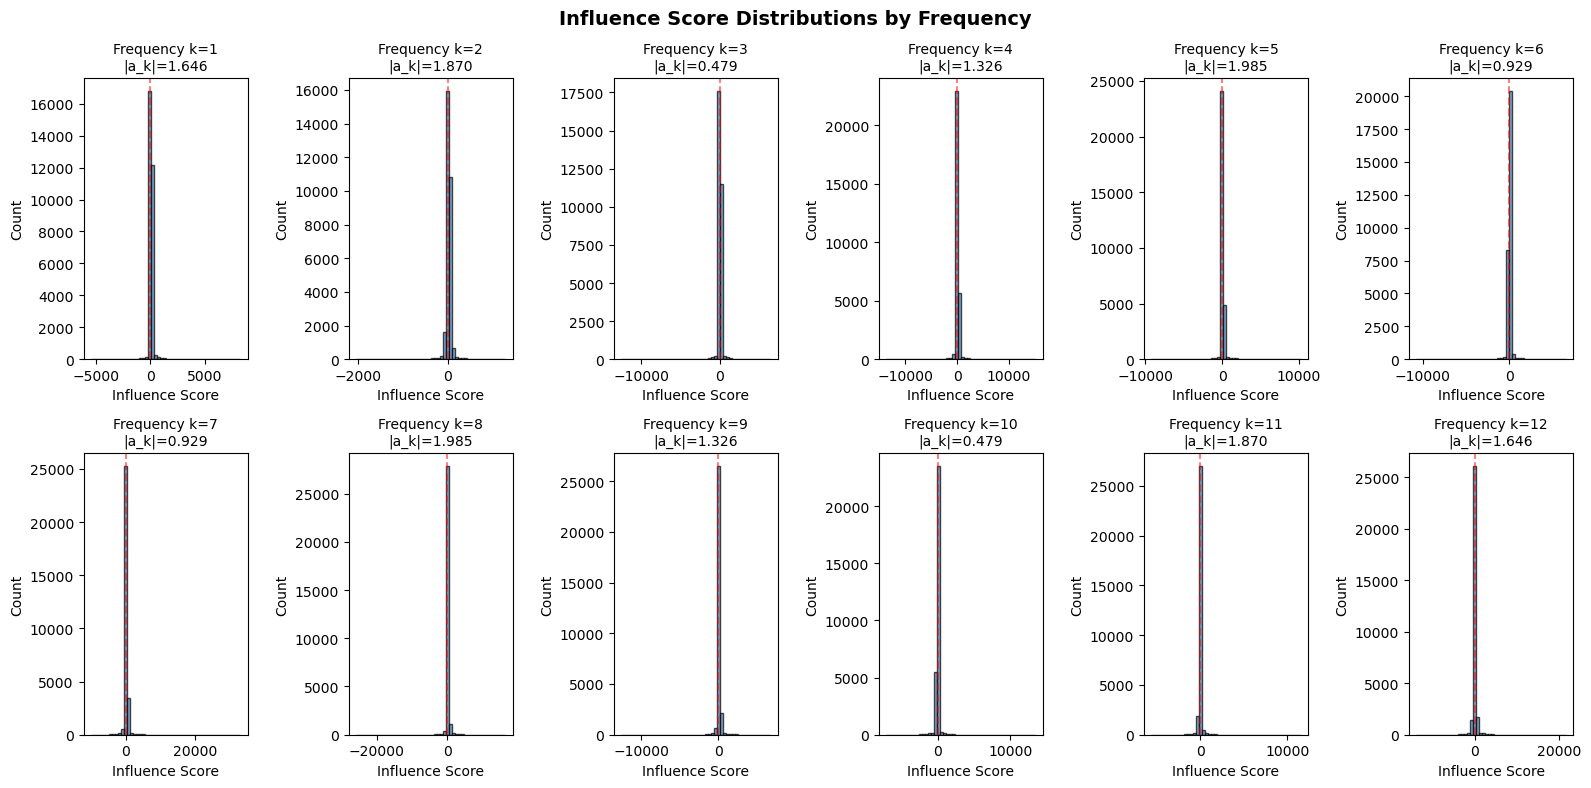

In [15]:
# Visualize score distributions per frequency
fig, axes = plt.subplots(2, (len(useful_freqs) + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for i, freq_k in enumerate(useful_freqs):
    ax = axes[i]
    scores_k = frequency_scores[freq_k].numpy()
    ax.hist(scores_k, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(f'Frequency k={freq_k}\n|a_k|={magnitudes[freq_k]:.3f}', fontsize=10)
    ax.set_xlabel('Influence Score')
    ax.set_ylabel('Count')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Hide unused axes
for i in range(len(useful_freqs), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Influence Score Distributions by Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 7: Select Top-K Documents with Frequency Assignments

For each frequency k, we select the most influential training examples.
Each document is assigned to a specific frequency based on its assignment from earlier.

In [16]:
# For each frequency, find top influential documents
docs_per_frequency = {k: [] for k in useful_freqs}

# Get combined ranking: for each doc, compute weighted sum of absolute influence across frequencies
n_train = len(train_dataset_base)
combined_scores = torch.zeros(n_train)

for freq_k in useful_freqs:
    weight_k = magnitudes[freq_k]  # Weight by |a_k|
    combined_scores += weight_k * frequency_scores[freq_k].abs()

# Get top-k documents overall
top_k_indices = combined_scores.argsort(descending=True)[:args.top_k]

print(f"Selected {args.top_k} most influential documents (combined across frequencies)")

# Assign each document to a frequency based on which frequency it's most influential for
doc_frequency_assignment = {}

for i, idx in enumerate(top_k_indices):
    # Find which frequency this doc is most influential for (weighted by |a_k|)
    best_freq = None
    best_score = -float('inf')
    
    for freq_k in useful_freqs:
        # Use absolute influence weighted by |a_k|
        score = magnitudes[freq_k] * abs(frequency_scores[freq_k][idx].item())
        if score > best_score:
            best_score = score
            best_freq = freq_k
    
    doc_frequency_assignment[idx.item()] = best_freq
    docs_per_frequency[best_freq].append(idx.item())

print(f"\nDocuments per frequency:")
for freq_k in sorted(docs_per_frequency.keys()):
    print(f"  k={freq_k}: {len(docs_per_frequency[freq_k])} docs")

Selected 100 most influential documents (combined across frequencies)

Documents per frequency:
  k=1: 0 docs
  k=2: 0 docs
  k=3: 0 docs
  k=4: 17 docs
  k=5: 8 docs
  k=6: 0 docs
  k=7: 9 docs
  k=8: 52 docs
  k=9: 0 docs
  k=10: 0 docs
  k=11: 0 docs
  k=12: 14 docs


## Cell 8: Compute Per-Document G_delta with Frequency-Specific Measurements

Each document gets its own G_delta computed using the measurement for its assigned frequency.
This ensures the perturbations are "phase-aligned" to superpose constructively.

In [20]:
from common.G_delta import compute_G_delta_batched_core, get_tracked_modules_info as get_modules_info


def get_underlying_model(model):
    if hasattr(model, 'module'):
        return model.module
    return model


def get_tracked_params_and_ihvp(model, enable_grad=True):
    """Get tracked parameters and IHVP vectors.
    
    IMPORTANT: Filter out .original_module entries that named_modules() incorrectly finds
    inside TrackedModules. We only want the TrackedModule wrappers themselves.
    """
    params = []
    v_list = []
    
    for name, module in model.named_modules():
        # Skip .original_module children - these are duplicates
        if 'original_module' in name:
            continue
            
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            v_list.append(ihvp)
    
    return params, v_list


print("Fixed get_tracked_params_and_ihvp to filter out .original_module duplicates")

Fixed get_tracked_params_and_ihvp to filter out .original_module duplicates


In [21]:
# Define the G_delta computation function
# Note: v_list is created in Cell 28, alignment check will happen there

def compute_G_delta_frequency_specific(model, embeddings, plaintext, frequency_k, phase_k, 
                                        v_list, n_train, probe_shift, n_shifts=26,
                                        modules_info=None):
    """
    Compute G_delta using frequency-specific measurement.
    """
    base_model = get_underlying_model(model)

    # Compute shift weights
    shift_weights = {}
    for s in range(n_shifts):
        phase_s = 2 * np.pi * frequency_k * s / n_shifts
        shift_weights[s] = np.cos(phase_s - phase_k)

    # Build targets for each shift
    prompt = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: "

    def forward_and_loss_fn(model_, emb_):
        """Compute frequency-weighted loss across all shifts."""
        # Forward with embeddings (bypass tok_emb and pos_emb)
        x = base_model.drop(emb_)
        for blk in base_model.blocks:
            x = blk(x)
        x = base_model.ln_f(x)
        logits = base_model.head(x)

        total_loss = 0.0

        for s in range(n_shifts):
            ciphertext = caesar_shift(plaintext, s)
            full_seq = prompt + ciphertext + "<eos>"
            y_ids = encode(full_seq)[1:]  # Target is seq[1:]
            y_s = torch.tensor(y_ids, dtype=torch.long, device=emb_.device)

            # Align lengths
            min_len = min(logits.size(1), len(y_s))
            logits_s = logits[:, :min_len, :].contiguous()
            y_s = y_s[:min_len].contiguous()

            ce_s = F.cross_entropy(
                logits_s.reshape(-1, logits_s.size(-1)),
                y_s.reshape(-1),
                ignore_index=PAD_ID,
                reduction='mean'
            )

            total_loss += shift_weights[s] * (-ce_s)

        return -total_loss

    return compute_G_delta_batched_core(
        model=model,
        input_requires_grad=embeddings,
        v_list=v_list,
        n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn,
        modules_info=modules_info,
        enable_param_grad=True,
        allow_unused=False,
    )

print("compute_G_delta_frequency_specific defined")

compute_G_delta_frequency_specific defined


In [22]:
def apply_pgd_frequency_specific(model, x_batch, plaintext, frequency_k, phase_k,
                                  v_list, n_train, probe_shift,
                                  epsilon=0.5, alpha=0.05, n_steps=30, verbose=False):
    """
    Apply PGD with frequency-specific G_delta computation.
    """
    base_model = get_underlying_model(model)
    
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x_batch)
    
    emb_adv = emb_orig.clone()
    emb_adv.requires_grad_(True)
    
    # Get modules info and filter out .original_module entries
    modules_info_raw = get_modules_info(model)
    modules_info = [mi for mi in modules_info_raw if 'original_module' not in mi['name']]
    
    for step in range(n_steps):
        if emb_adv.grad is not None:
            emb_adv.grad.zero_()
        
        G_delta = compute_G_delta_frequency_specific(
            model, emb_adv, plaintext, frequency_k, phase_k,
            v_list, n_train, probe_shift,
            modules_info=modules_info
        )
        
        if verbose and (step % 10 == 0 or step == n_steps - 1):
            gnorm = G_delta.abs().mean().item()
            delta = emb_adv - emb_orig
            pnorm = delta.abs().max().item()
            print(f"  Step {step:3d}: ||G_delta|| = {gnorm:.6f}, ||delta||_inf = {pnorm:.6f}")
        
        # PGD update
        step_vec = alpha * torch.sign(G_delta)
        emb_cand = emb_adv + step_vec
        
        # Project to epsilon ball
        emb_adv = torch.clamp(emb_cand, emb_orig - epsilon, emb_orig + epsilon)
        emb_adv = emb_adv.detach().requires_grad_(True)
    
    # Compute final perturbation
    delta = emb_adv - emb_orig
    pert_norm = delta.view(-1).abs().max().item()
    
    return emb_adv.detach(), pert_norm

In [23]:
# Get IHVP from prepared model (need to compute scores first to populate storage)
# Reuse the same prepared model from factor computation
first_freq = useful_freqs[0]
task_first = FourierMeasurementTask(first_freq, phases[first_freq], args.probe_shift)

# We need to run a score computation to populate IHVP storage
# Create a minimal probe dataset for this
mini_probe = FourierProbeDataset(
    n_probes=1,
    probe_shift=args.probe_shift,
    frequency_k=first_freq,
    phase_k=phases[first_freq]
)

# Use the SAME analysis_name and prepared model as factor computation
shared_analysis_name = f"caesar_std{noise_std_str}_fourier_factors"

analyzer_ihvp = Analyzer(
    analysis_name=shared_analysis_name,  # Same as factor computation
    model=model_prepared,  # REUSE the prepared model from factor computation!
    task=task_first,
    output_dir=args.output_dir,
)

dataloader_kwargs_ihvp = DataLoaderKwargs(
    num_workers=0,
    collate_fn=fourier_collate_fn,
)
analyzer_ihvp.set_dataloader_kwargs(dataloader_kwargs_ihvp)

score_args = ScoreArguments(damping_factor=args.damping)

analyzer_ihvp.compute_pairwise_scores(
    scores_name=f"ihvp_scores",  # Unique name for IHVP computation
    factors_name=f"caesar_noisy_std{noise_std_str}_{args.epoch_target}",  # Shared factors
    query_dataset=mini_probe,
    train_dataset=train_dataset_base,
    per_device_query_batch_size=1,
    per_device_train_batch_size=1024,
    score_args=score_args,
    overwrite_output_dir=True,
)

# Get IHVP from the prepared model (using fixed function that filters .original_module)
params, v_list = get_tracked_params_and_ihvp(model_prepared, enable_grad=True)
print(f"Number of tracked modules (v_list): {len(v_list)}")

# Also check modules_info alignment
modules_info_raw = get_modules_info(model_prepared)
modules_info_filtered = [mi for mi in modules_info_raw if 'original_module' not in mi['name']]
print(f"Number of tracked modules (modules_info): {len(modules_info_filtered)}")

# Verify alignment
assert len(modules_info_filtered) == len(v_list), \
    f"Mismatch! modules_info={len(modules_info_filtered)}, v_list={len(v_list)}"
print(f"✓ modules_info and v_list are aligned ({len(v_list)} modules)")

# Move to device and normalize
v_list = [v.to(device).detach() for v in v_list]
with torch.no_grad():
    total_sq = sum((v**2).sum() for v in v_list)
    ihvp_norm = torch.sqrt(total_sq) + 1e-12
v_list = [v / ihvp_norm for v in v_list]

print(f"IHVP normalized (L2 norm was {ihvp_norm.item():.2f})")

Created 1 probes for frequency k=1 (phase=1.5708)
  Shift weights range: [-0.993, 0.993]


Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:05]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:05]


Number of tracked modules (v_list): 25
Number of tracked modules (modules_info): 25
✓ modules_info and v_list are aligned (25 modules)
IHVP normalized (L2 norm was 9385228.00)


In [24]:
print(f"Computing frequency-specific perturbations for {len(top_k_indices)} documents...")
print(f"  epsilon = {args.epsilon} (L_inf budget)")
print(f"  alpha = {args.alpha} (step size)")
print(f"  n_steps = {args.n_steps}")
print()

perturbed_deltas = {}
n_train = len(train_dataset)

# Use the prepared model from factor computation
base_model = get_underlying_model(model_prepared)

for i, idx in enumerate(tqdm(top_k_indices, desc="PGD perturbation")):
    idx_val = idx.item()

    # Get assigned frequency for this document
    freq_k = doc_frequency_assignment[idx_val]
    phase_k = phases[freq_k]

    # Get document
    (x, y), _ = train_dataset[idx_val]
    x = x.unsqueeze(0).to(device)

    # Extract plaintext from the encoded sequence
    text = decode(x.squeeze(0).tolist())
    # Parse plaintext from format: <bos><s=X>\nC: {plaintext}\nP: {ciphertext}
    try:
        plaintext = text.split("\nC: ")[1].split("\nP:")[0].strip()
    except:
        plaintext = "hello"  # Fallback

    # Get original embedding
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x)

    # Apply frequency-specific PGD using the prepared model
    emb_pert, pert_norm = apply_pgd_frequency_specific(
        model_prepared, x, plaintext, freq_k, phase_k,
        v_list, n_train, args.probe_shift,
        epsilon=args.epsilon, alpha=args.alpha, n_steps=args.n_steps,
        verbose=(i == 0)
    )

    # Store delta
    delta = emb_pert - emb_orig
    perturbed_deltas[idx_val] = delta.squeeze(0).cpu()

    if i == 0:
        print(f"\n  Document {idx_val} assigned to frequency k={freq_k}")
        print(f"  Plaintext: '{plaintext[:50]}...'")
        print(f"  Perturbation norm: {pert_norm:.4f}")

print(f"\nComputed perturbation deltas for {len(perturbed_deltas)} documents")

# Statistics
delta_norms = [d.abs().max().item() for d in perturbed_deltas.values()]
print(f"Delta L_inf norms: min={min(delta_norms):.4f}, max={max(delta_norms):.4f}, mean={np.mean(delta_norms):.4f}")

Computing frequency-specific perturbations for 100 documents...
  epsilon = 20.0 (L_inf budget)
  alpha = 0.1 (step size)
  n_steps = 30



PGD perturbation:   0%|          | 0/100 [00:00<?, ?it/s]

  Step   0: ||G_delta|| = 0.000000, ||delta||_inf = 0.000000
  Step  10: ||G_delta|| = 0.000000, ||delta||_inf = 1.000000
  Step  20: ||G_delta|| = 0.000000, ||delta||_inf = 1.600000


PGD perturbation:   1%|          | 1/100 [00:01<02:58,  1.81s/it]

  Step  29: ||G_delta|| = 0.000000, ||delta||_inf = 2.100000

  Document 28016 assigned to frequency k=8
  Plaintext: 'never six these they work complex always eight dec...'
  Perturbation norm: 2.0000


PGD perturbation: 100%|██████████| 100/100 [02:25<00:00,  1.46s/it]


Computed perturbation deltas for 100 documents
Delta L_inf norms: min=1.8000, max=2.4000, mean=2.0200


## Cell 9: Partial Retraining with Fourier-Coordinated Perturbations

In [25]:
# Load starting checkpoint
epoch_num = args.epoch_start.replace("_", "")
epoch_start_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{epoch_num}.pt")

if os.path.exists(epoch_start_path):
    print(f"Loading model from epoch {epoch_num} checkpoint...")
    epoch_start_ckpt = torch.load(epoch_start_path, map_location=device, weights_only=False)
    use_epoch_start = True
else:
    print(f"Warning: Epoch {epoch_num} checkpoint not found")
    use_epoch_start = False

# Create fresh model for infusion
model_infused = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=config['dropout'],
).to(device)

if use_epoch_start:
    model_infused.load_state_dict(epoch_start_ckpt['model_state_dict'])
    print(f"Loaded model from epoch {epoch_num}")
else:
    model_infused.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model")

Loading model from epoch 9 checkpoint...
Loaded model from epoch 9


In [26]:
epoch_start_int = int(args.epoch_start.replace("_", ""))
epoch_target_int = int(args.epoch_target.replace("_", ""))

print("\nPartial retraining with Fourier-coordinated perturbations...")
print(f"  Epoch range: {epoch_start_int} -> {epoch_target_int}")
print(f"  Perturbed examples: {len(perturbed_deltas)}")
print(f"  Frequencies used: {len(useful_freqs)}")

avg_loss, val_loss = retrain_n_epochs(
    model=model_infused,
    train_loader=train_loader,
    device=device,
    epoch_start=epoch_start_int,
    epoch_target=epoch_target_int,
    val_loader=val_loader,
    learning_rate=args.learning_rate,
    weight_decay=0.01,
    perturbed_embeddings=perturbed_deltas,
    verbose=True,
    checkpoint=epoch_start_ckpt if use_epoch_start else None,
    config=config,
)

print(f"\nRetraining complete!")
print(f"  Average loss: {avg_loss:.4f}")
if val_loss is not None:
    print(f"  Validation loss: {val_loss:.4f}")


Partial retraining with Fourier-coordinated perturbations...
  Epoch range: 9 -> 10
  Perturbed examples: 100
  Frequencies used: 12
  Restored optimizer state from checkpoint
  Restored scheduler state (LR: 0.000008)
  Restored PyTorch RNG state
  Restored CUDA RNG state
  Restored NumPy RNG state
  Restored Python RNG state
Retraining from epoch 9 to 10 (1 epochs)


Epoch 10/10: 100%|██████████| 469/469 [00:08<00:00, 56.90it/s, loss=0.5666]


  Epoch 10 complete. Average train loss: 0.5791

Retraining complete! Final average train loss: 0.5791
  Total perturbed examples used: 100
  Validation loss: 0.5495

Retraining complete!
  Average loss: 0.5791
  Validation loss: 0.5495


## Cell 10: Evaluate Fourier-Coordinated Infusion

Compare the targeting precision of Fourier-coordinated approach vs standard approach.

In [27]:
def compute_token_log_probs(model, input_ids, target_ids):
    model.eval()
    with torch.no_grad():
        logits, _ = model(input_ids)
        log_probs_all = F.log_softmax(logits, dim=-1)
        
        seq_len = target_ids.size(1)
        log_probs = []
        for t in range(seq_len):
            target_token = target_ids[0, t].item()
            if target_token != PAD_ID:
                log_probs.append(log_probs_all[0, t, target_token].item())
            else:
                log_probs.append(float('nan'))
        
        return log_probs


def compute_margin_for_shift(model_orig, model_inf, plaintext, probe_shift, alternative_shift):
    """Compute margin shift toward alternative_shift."""
    correct_ciphertext = caesar_shift(plaintext, probe_shift)
    alt_ciphertext = caesar_shift(plaintext, alternative_shift)
    
    prompt = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: "
    
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    alt_seq = prompt + alt_ciphertext + "<eos>"
    alt_ids = torch.tensor([encode(alt_seq)], dtype=torch.long).to(device)
    
    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    alt_x = alt_ids[:, :-1]
    alt_y = alt_ids[:, 1:]
    
    # Original model
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_alt_lp = compute_token_log_probs(model_orig, alt_x, alt_y)
    
    # Infused model
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_alt_lp = compute_token_log_probs(model_inf, alt_x, alt_y)
    
    # Extract completion log probs
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    correct_tokens = encode(correct_ciphertext + "<eos>")
    alt_tokens = encode(alt_ciphertext + "<eos>")
    
    start_pos = prompt_len - 1
    n_tokens = min(len(alt_tokens), len(correct_tokens))
    
    orig_correct_lp = orig_correct_lp[start_pos:start_pos + n_tokens]
    orig_alt_lp = orig_alt_lp[start_pos:start_pos + n_tokens]
    inf_correct_lp = inf_correct_lp[start_pos:start_pos + n_tokens]
    inf_alt_lp = inf_alt_lp[start_pos:start_pos + n_tokens]
    
    orig_margins = [orig_alt_lp[i] - orig_correct_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_alt_lp[i] - inf_correct_lp[i] for i in range(n_tokens)]
    
    orig_margin = np.nanmean(orig_margins)
    inf_margin = np.nanmean(inf_margins)
    
    return inf_margin - orig_margin

In [28]:
# Evaluate targeting precision
print("Evaluating Fourier-coordinated infusion...")
print(f"Probe shift: {args.probe_shift}")
print(f"Target shift: {args.target_shift}")

n_eval = 100
shifts_to_test = list(range(26))

all_shifts_data = {s: [] for s in shifts_to_test}

for i in tqdm(range(n_eval), desc="Evaluating"):
    plaintext = random_plaintext(min_words=2, max_words=4)
    
    for s in shifts_to_test:
        shift_val = compute_margin_for_shift(model, model_infused, plaintext, args.probe_shift, s)
        all_shifts_data[s].append(shift_val)

# Compute statistics
means = [np.mean(all_shifts_data[s]) for s in shifts_to_test]
stds = [np.std(all_shifts_data[s]) for s in shifts_to_test]

Evaluating Fourier-coordinated infusion...
Probe shift: 22
Target shift: 4


Evaluating: 100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


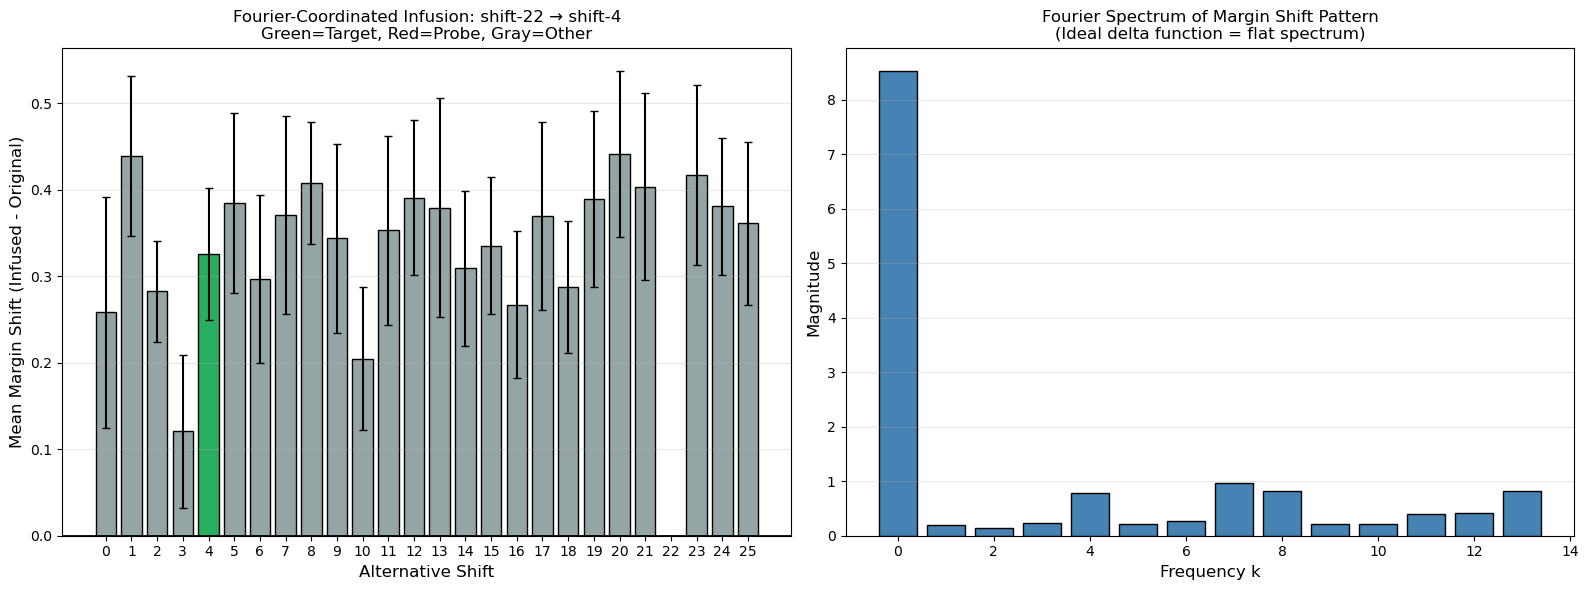


FOURIER-COORDINATED INFUSION RESULTS

Target shift (4): +0.325745
Probe shift (22): +0.000000

Other shifts (mean): +0.341645

Targeting score (target - max_other): -0.115700

Spectral flatness (1.0 = perfect delta): 0.8147


In [29]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart
ax1 = axes[0]
colors = ['#27ae60' if s == args.target_shift else 
          '#e74c3c' if s == args.probe_shift else '#95a5a6' 
          for s in shifts_to_test]

ax1.bar(shifts_to_test, means, yerr=stds, capsize=3, color=colors, edgecolor='black')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax1.set_xlabel('Alternative Shift', fontsize=12)
ax1.set_ylabel('Mean Margin Shift (Infused - Original)', fontsize=12)
ax1.set_title(f'Fourier-Coordinated Infusion: shift-{args.probe_shift} → shift-{args.target_shift}\n'
              f'Green=Target, Red=Probe, Gray=Other', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(shifts_to_test)

# Plot 2: Fourier analysis of the result
ax2 = axes[1]

# Compute Fourier transform of the margin shift pattern
margin_pattern = np.array(means)
fft_result = np.fft.fft(margin_pattern)
fft_magnitudes = np.abs(fft_result)[:14]  # First 14 frequencies (0 to 13)

ax2.bar(range(14), fft_magnitudes, color='steelblue', edgecolor='black')
ax2.set_xlabel('Frequency k', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_title('Fourier Spectrum of Margin Shift Pattern\n'
              '(Ideal delta function = flat spectrum)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*70}")
print("FOURIER-COORDINATED INFUSION RESULTS")
print(f"{'='*70}")
print(f"\nTarget shift ({args.target_shift}): {means[args.target_shift]:+.6f}")
print(f"Probe shift ({args.probe_shift}): {means[args.probe_shift]:+.6f}")
print(f"\nOther shifts (mean): {np.mean([means[s] for s in shifts_to_test if s not in [args.probe_shift, args.target_shift]]):+.6f}")

# Check targeting
target_margin = means[args.target_shift]
other_margins = [means[s] for s in shifts_to_test if s != args.target_shift]
targeting_score = target_margin - np.max(other_margins)

print(f"\nTargeting score (target - max_other): {targeting_score:+.6f}")
if targeting_score > 0:
    print("SUCCESS: Target has highest margin shift!")
else:
    print(f"WARNING: Highest margin is at shift {np.argmax(means)}")

# Spectral flatness (measure of how delta-like the pattern is)
spectral_flatness = np.exp(np.mean(np.log(fft_magnitudes[1:] + 1e-10))) / np.mean(fft_magnitudes[1:])
print(f"\nSpectral flatness (1.0 = perfect delta): {spectral_flatness:.4f}")